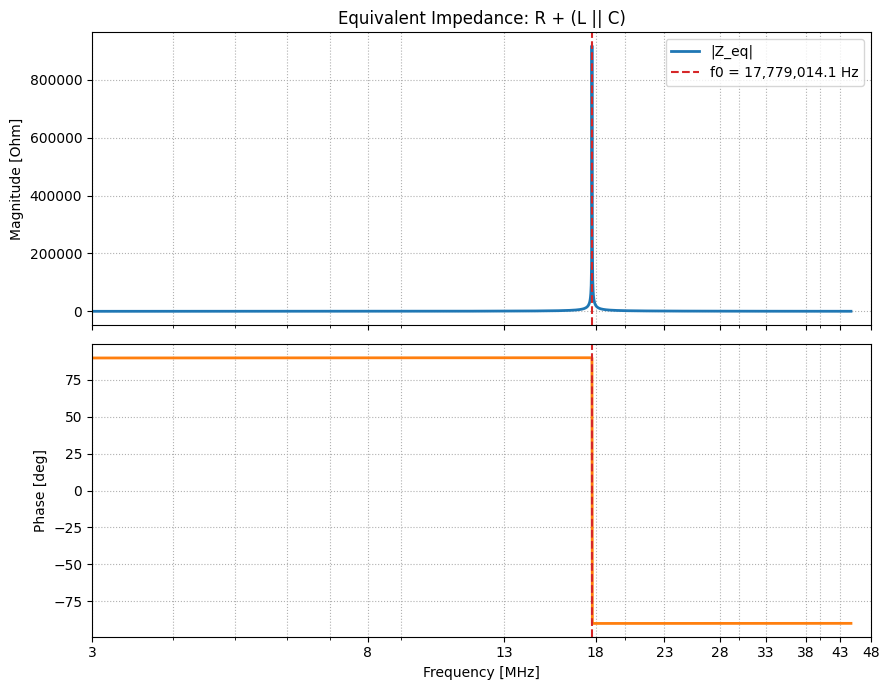

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
from matplotlib.figure import Figure

#Fitted parameters
#R = 0.25742 ohm
#L = 4.83872 uH
#C = 16.5613 pF
# R series - (L || C) parallel circuit parameters
R = 0.25742        # ohm
L = 4.83872e-6      # H
C = 16.5613e-12     # F

# Frequency sweep
f = np.logspace(6.47, 7.65, 2000)
w = 2 * np.pi * f

# Element impedances
Z_L = 1j * w * L
Z_C = 1 / (1j * w * C)

# Parallel LC impedance and total equivalent impedance
Z_LC = (Z_L * Z_C) / (Z_L + Z_C)
Z_eq = R + Z_LC

# Resonant frequency of ideal LC
f0 = 1 / (2 * np.pi * np.sqrt(L * C))

fig_ax: tuple[Figure, np.ndarray] = plt.subplots(2, 1, figsize=(9, 7), sharex=True)  # type: ignore
fig, ax = fig_ax

ax[0].semilogx(f, np.abs(Z_eq), label='|Z_eq|', linewidth=2)
ax[0].axvline(f0, color='tab:red', linestyle='--', label=f'f0 = {f0:,.1f} Hz')
ax[0].set_ylabel('Magnitude [Ohm]')
ax[0].set_title('Equivalent Impedance: R + (L || C)')
ax[0].grid(True, which='both', ls=':')
ax[0].legend()

ax[1].semilogx(f, np.angle(Z_eq, deg=True), color='tab:orange', linewidth=2)
ax[1].axvline(f0, color='tab:red', linestyle='--')
ax[1].set_ylabel('Phase [deg]')
ax[1].grid(True, which='both', ls=':')

# Show x-axis ticks from 3 MHz in 5 MHz steps
x_min = 3e6
x_max = f.max()
ticks = np.arange(x_min, x_max + 5e6, 5e6)
ax[1].set_xlim(x_min, x_max)
ax[1].set_xticks(ticks)
ax[1].set_xticklabels([f'{t/1e6:.0f}' for t in ticks])
ax[1].set_xlabel('Frequency [MHz]')

plt.tight_layout()
plt.show()


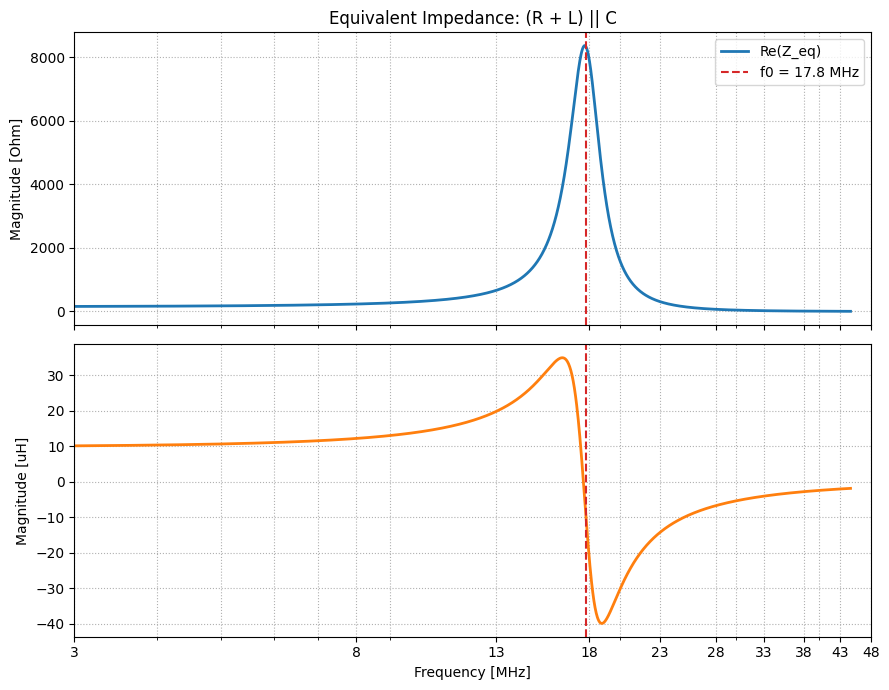

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
from matplotlib.figure import Figure

# R series - (L || C) parallel circuit parameters
R = 150        # ohm
L = 10e-6     # H
C = 8e-12       # F

# Frequency sweep
f = np.logspace(6.47, 7.65, 2000)  # 100 Hz ~ 1 MHz
w = 2 * np.pi * f

# Element impedances
Z_L = 1j * w * L
Z_C = 1 / (1j * w * C)

# Parallel LC impedance and total equivalent impedance
Z_RL = R + Z_L
Z_eq = (Z_RL * Z_C) / (Z_RL + Z_C)


# Resonant frequency of ideal LC
f0 = 1 / (2 * np.pi * np.sqrt(L * C))

fig_ax:tuple[list[Figure], list[Axes]]  = plt.subplots(2, 1, figsize=(9, 7), sharex=True) # type: ignore
fig, ax = fig_ax
ax[0].semilogx(f, np.real(Z_eq), label='Re(Z_eq)', linewidth=2)
ax[0].axvline(f0, color='tab:red', linestyle='--', label=f'f0 = {f0/1e6:,.1f} MHz')
ax[0].set_ylabel('Magnitude [Ohm]')
ax[0].set_title('Equivalent Impedance: (R + L) || C')
ax[0].grid(True, which='both', ls=':')
ax[0].legend()

ax[1].semilogx(f, np.imag(Z_eq)/2/np.pi/f*1e6, color='tab:orange', linewidth=2)
ax[1].axvline(f0, color='tab:red', linestyle='--')
ax[1].set_xlabel('Frequency [Hz]')
ax[1].set_ylabel('Magnitude [uH]')
ax[1].grid(True, which='both', ls=':')

x_min = 3e6
x_max = f.max()
ticks = np.arange(x_min, x_max + 5e6, 5e6)
ax[1].set_xlim(x_min, x_max)
ax[1].set_xticks(ticks)
ax[1].set_xticklabels([f'{t/1e6:.0f}' for t in ticks])
ax[1].set_xlabel('Frequency [MHz]')
plt.tight_layout()
plt.show()


In [4]:
import sympy as sp
from IPython.display import display, Math

# Notebook LaTeX rendering
sp.init_printing(use_latex='mathjax')

# Symbols
R, L, C, w = sp.symbols('R L C w', positive=True, real=True)
j = sp.I

# Circuit: Z_eq = (R + j*w*L) || (1/(j*w*C))
Z_RL = R + j*w*L
Z_C = 1 / (j*w*C)
Z_eq = sp.simplify((Z_RL * Z_C) / (Z_RL + Z_C))

Re_Z = sp.simplify(sp.re(Z_eq))
Im_Z = sp.simplify(sp.im(Z_eq))
L_eff = sp.simplify(Im_Z / w)  # series-equivalent inductance [H]
L_eff_uH = sp.simplify(L_eff * sp.Integer(10)**6)

# Text output (plain)
# print('Z_eq =')
# sp.pprint(Z_eq)
# print('\\nRe(Z_eq) =')
# sp.pprint(Re_Z)
# print('\\nIm(Z_eq) =')
# sp.pprint(Im_Z)
# print('\\nL_eff = Im(Z_eq)/w [H] =')
# sp.pprint(L_eff)
# print('\\nL_eff [uH] =')
# sp.pprint(L_eff_uH)

# LaTeX-rendered output
display(Math(r'Z_{eq} = ' + sp.latex(Z_eq)))
display(Math(r'\\Re(Z_{eq}) = ' + sp.latex(Re_Z)))
display(Math(r'\\Im(Z_{eq}) = ' + sp.latex(Im_Z)))
display(Math(r'L_{\\mathrm{eff}} = ' + sp.latex(L_eff)))
display(Math(r'L_{\\mathrm{eff}}[u H] = ' + sp.latex(L_eff_uH)))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [5]:
import numpy as np
from scipy.optimize import least_squares

# Measured points: (frequency [MHz], L_eff [uH])
f_mhz = np.array([3.45, 15.547, 17.779, 19.67], dtype=float)
Leff_uH_meas = np.array([10.26, 24.9, 0.0, -16.25], dtype=float)

f = f_mhz * 1e6
w = 2.0 * np.pi * f

def leff_model_uH(w_rad_s: np.ndarray, R: float, L: float, C: float) -> np.ndarray:
    # Circuit: Z_eq = (R + j*w*L) || (1/(j*w*C)), and L_eff = Im(Z_eq)/w
    den = (1.0 - C*L*w_rad_s**2)**2 + (C*R*w_rad_s)**2
    num = L - C*R**2 - C*L**2*w_rad_s**2
    return (num / den) * 1e6  # [uH]

def residual(theta_log: np.ndarray) -> np.ndarray:
    R, L, C = np.exp(theta_log)  # enforce positivity
    pred = leff_model_uH(w, R, L, C)
    return pred - Leff_uH_meas

# Initial guess (close to your current setup)
x0 = np.log(np.array([150.0, 10e-6, 8e-12], dtype=float))
res = least_squares(residual, x0, method='trf')
R_fit, L_fit, C_fit = np.exp(res.x)

Leff_fit_uH = leff_model_uH(w, R_fit, L_fit, C_fit)
rmse_uH = np.sqrt(np.mean((Leff_fit_uH - Leff_uH_meas)**2))

print('Fitted parameters')
print(f'R = {R_fit:.6g} ohm')
print(f'L = {L_fit*1e6:.6g} uH')
print(f'C = {C_fit*1e12:.6g} pF')
print(f'RMSE = {rmse_uH:.6g} uH')

print('\\nPoint-by-point (measured -> fitted)')
for fm, ym, yp in zip(f_mhz, Leff_uH_meas, Leff_fit_uH):
    print(f'{fm:8.3f} MHz : {ym:9.4f} uH -> {yp:9.4f} uH  (err {yp-ym:+9.4f})')


Fitted parameters
R = 0.25742 ohm
L = 4.83872 uH
C = 16.5613 pF
RMSE = 4.32411 uH
\nPoint-by-point (measured -> fitted)
   3.450 MHz :   10.2600 uH ->    5.0280 uH  (err   -5.2320)
  15.547 MHz :   24.9000 uH ->   20.5620 uH  (err   -4.3380)
  17.779 MHz :    0.0000 uH ->   -0.0003 uH  (err   -0.0003)
  19.670 MHz :  -16.2500 uH ->  -21.5979 uH  (err   -5.3479)
